In [1]:
import numpy as np
import pandas as pd

# pip install import-ipynb
import sys, pathlib
sys.path.append(str(pathlib.Path("MOIC_Inventory/ipynbFile").resolve()))
import import_ipynb  # enables importing .ipynb modules

import ipynbFile.InventorySim as invSim
import ipynbFile.DemandSeries as demSer

In [2]:
import zipfile
zf = zipfile.ZipFile('G:\MOIC\MOIC_Inventory\DataRaw\m5-forecasting-accuracy.zip')

sales_val = pd.read_csv(zf.open('sales_train_validation.csv'))
calendar_val = pd.read_csv(zf.open('calendar.csv'))
sell_prices_val = pd.read_csv(zf.open('sell_prices.csv'))

In [3]:
sales_val.head(5)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [4]:
#Phân loại các kiểu demand
id_col = 'id'
cat_cols = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
value_cols = [f'd_{i}' for i in range(1, 1913)]

sales_series = demSer.DemandSeries(sales_val, id_col, value_cols, cat_cols)

sales_series.classify_demand()


['Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Erratic',
 'Erratic',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Lumpy',
 'Erratic',
 'Lu

In [5]:
#Ví dụ mô phỏng tồn kho cho 1 mã
item_id = 'HOBBIES_1_001_CA_1_validation'
item_series = sales_series.get_series([item_id], drop_index=False)

item_series = pd.wide_to_long(item_series,
                          stubnames="d",
                          i="id",
                          j="d_time",
                          sep="_",
                          suffix="\d+").reset_index()
item_series

,id,d_time,d
0,HOBBIES_1_001_CA_1_validation,1,0
1,HOBBIES_1_001_CA_1_validation,2,0
2,HOBBIES_1_001_CA_1_validation,3,0
3,HOBBIES_1_001_CA_1_validation,4,0
4,HOBBIES_1_001_CA_1_validation,5,0
...,...,...,...
1907,HOBBIES_1_001_CA_1_validation,1908,1
1908,HOBBIES_1_001_CA_1_validation,1909,1
1909,HOBBIES_1_001_CA_1_validation,1910,3
1910,HOBBIES_1_001_CA_1_validation,1911,0


In [6]:
#Dự báo với trung bình trượt
window = 5          # số ngày lấy trung bình
horizon = 5         # số ngày cần dự báo

ma_last = item_series['d'].rolling(window=window, min_periods=1).mean().iloc[-1]

future_times = list(range(item_series['d_time'].max() + 1, item_series['d_time'].max() + 1 + horizon))
forecast_df = pd.DataFrame({
    'id': item_series['id'].iloc[0],
    'd_time': future_times,
    'd': [ma_last] * horizon
})

df_forecast = pd.concat([item_series, forecast_df], ignore_index=True)

In [9]:
intSim = invSim.InventorySimulation(0 ,item_series['d'], lead_time=3, review_period=2, service_level = 0.95, forecast_series = df_forecast['d'])

result = intSim.calculate_cost(price = 0.2, h=0.5, b=0.6, k=0.2, risk_type = 'R+L', return_breakdown = True)

In [11]:
result.keys()

dict_keys(['avg_cost_per_period', 'components', 's_t', 'S_t', 'trace'])

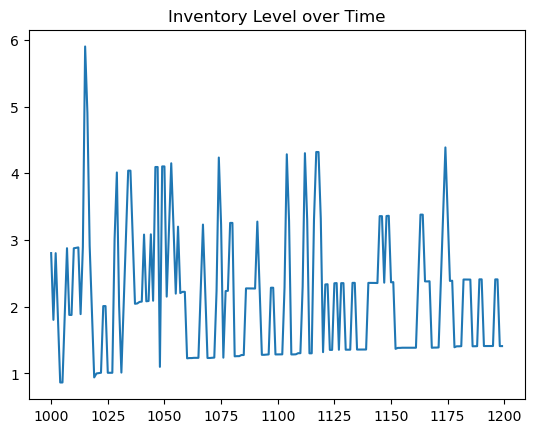

In [19]:
import matplotlib.pyplot as plt

# ví dụ result là dict trả về từ calculate_cost
trace = result['trace']

pd.Series(trace['I_t'])[1000:1200].plot(title="Inventory Level over Time")
plt.show()